In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

problems = [
    'Call_7_Vehicle_3.txt',
    'Call_18_Vehicle_5.txt',
    'Call_35_Vehicle_7.txt',
    'Call_80_Vehicle_20.txt',
    'Call_130_Vehicle_40.txt',
    'Call_300_Vehicle_90.txt'
]

def parse_df(problem, run):
    path = f'../measurements/{problem}/{run}.csv'
    df = pd.read_csv(path)
    df = df.pivot(index=['iteration'], columns='label', values='value').rename_axis(columns=None).reset_index()
    return df



In [8]:
def plot(problem, run=None):
    dfs = []
    for r in range(10):
        dfs.append(parse_df(problem, r))

    if run is None:        
        df = max(dfs, key=lambda df: df.best_cost.min())
    else:
        df = dfs[run]
    
    plt.plot(df['iteration'], df['temperature'])
    plt.xlabel('Iteration')
    plt.ylabel('Temperature')
    plt.title('Temperature vs. Iteration')
    plt.grid(True)
    plt.show()
    
    
    plt.scatter(df['iteration'], df['acceptance_probability'])
    plt.xlabel('Iteration')
    plt.ylabel('Acceptance')
    plt.ylim(-0.1, 1.1)
    plt.title('Acceptance vs. Iteration')
    plt.grid(True)
    plt.show()
    
    
    plt.plot(df['iteration'], df['best_cost'])
    plt.xlabel('Iteration')
    plt.ylabel('Best Cost')
    plt.title('Best Cost vs. Iteration')
    plt.grid(True)
    plt.show()
    
    
    plt.plot(df['iteration'], df['cost'])
    plt.xlabel('Iteration')
    plt.ylabel('Solution Cost')
    plt.title('Solution Cost vs. Iteration')
    plt.grid(True)
    plt.show()
    
    
    delta_columns = [col for col in df.columns if col.startswith('op') and col.endswith('delta')]
    
    # Create a separate plot for each delta column
    for column in delta_columns:
        plt.figure()  # Create a new figure for each plot
        plt.scatter(df['iteration'], df[column])
        plt.xlabel('Iteration')
        plt.ylabel(column)  # Use the column name as the y-axis label
        plt.title(f'{column} vs. Iteration')
        plt.grid(True)
        plt.show()
    
    
    
    delta_columns = [col for col in df.columns if col.startswith('op') and col.endswith('delta')]
    
    # # Create a separate plot for each delta column
    # for column in delta_columns:
    #     plt.figure()  # Create a new figure for each plot
    #     plt.scatter(df['iteration'], df[column])
    #     plt.xlabel('Iteration')
    #     plt.ylabel(column)  # Use the column name as the y-axis label
    #     plt.ylim(-1e4, 1e4)
    #     plt.title(f'{column} vs. Iteration')
    #     plt.grid(True)
    #     plt.show()
    
    
    
    prob_columns = [col for col in df.columns if col.startswith('op') and col.endswith('prob')]
    
    # Plot each prob column with a different color and label
    for column in prob_columns:
        plt.plot(df['iteration'], df[column], label=column)
    
    # Add legend, labels, title, and grid
    plt.legend()
    plt.xlabel('Iteration')
    plt.ylabel('Probability')
    plt.title('Operator Probabilities vs. Iteration')
    plt.grid(True)
    plt.show()

    best_iteration = []
    best_cost = []
    for i in range(10):
        df = dfs[i]
        best_iteration.append(df[df.cost == df.cost.min()].iteration.min())
        best_cost.append(df.cost.min())

    
    plt.scatter(best_iteration, np.random.normal(0, 0.1, 10), color='blue')
    plt.xlim(0, df.iteration.max())
    plt.ylim(-1, 1)
    plt.xlabel('Iteration')
    plt.title('Best Solution Iteration')
    plt.grid(True)
    plt.show()
    
    # Horizontal scatter plot
    plt.scatter(np.random.normal(0, 0.1, 10), best_cost, color='red')
    plt.xlim(-1, 1)
    plt.xlabel('Cost')
    plt.title("Best Solution Cost")
    plt.grid(True)
    plt.show()
        



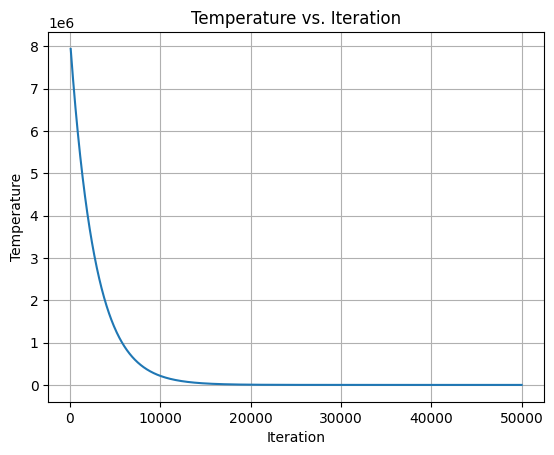

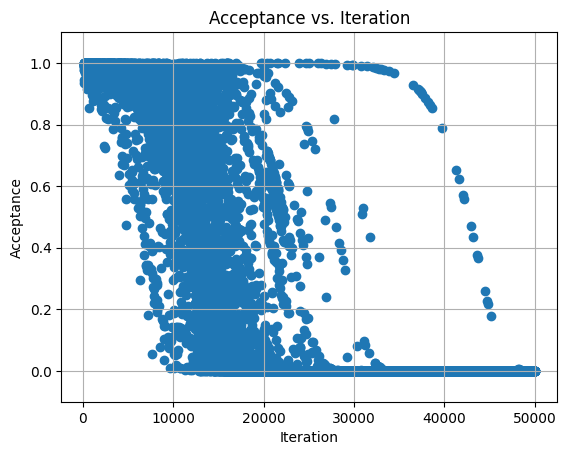

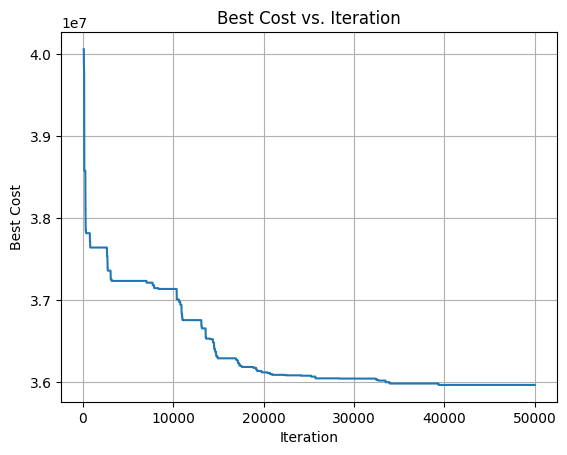

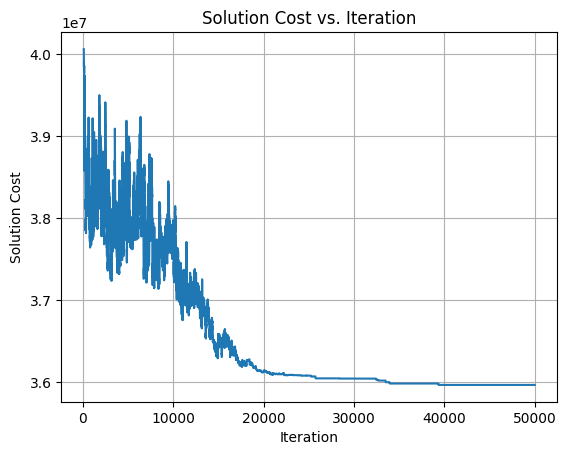

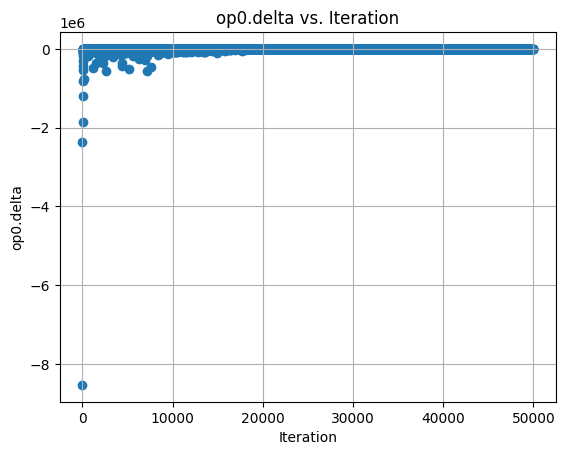

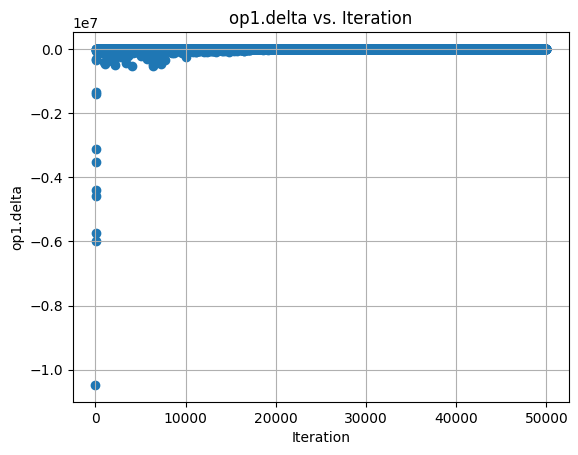

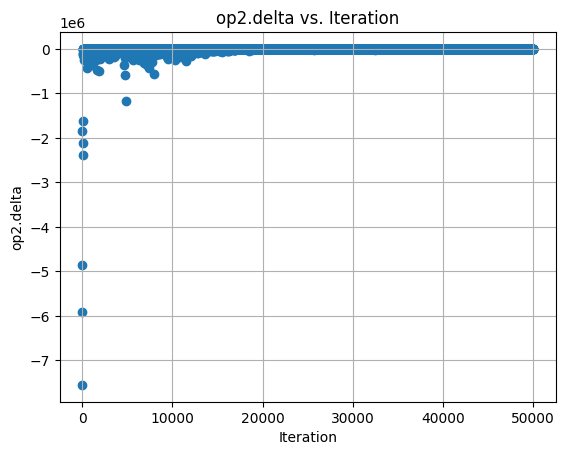

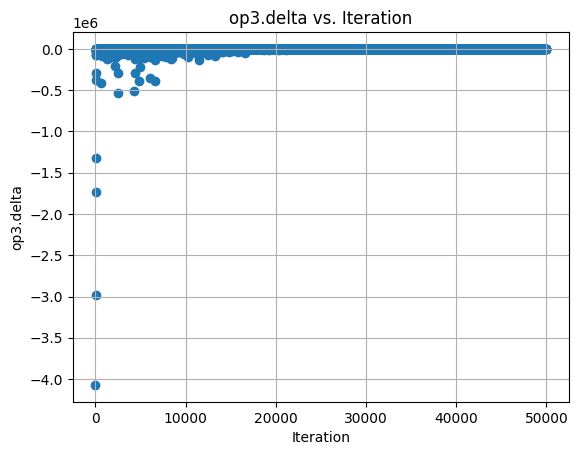

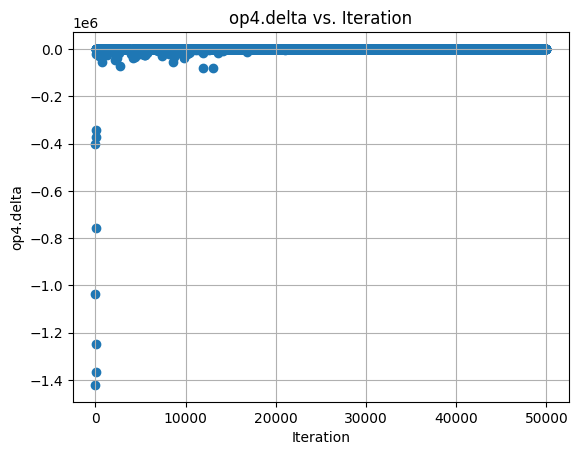

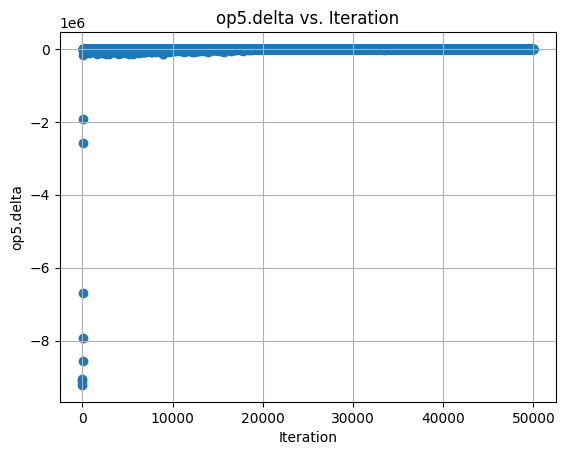

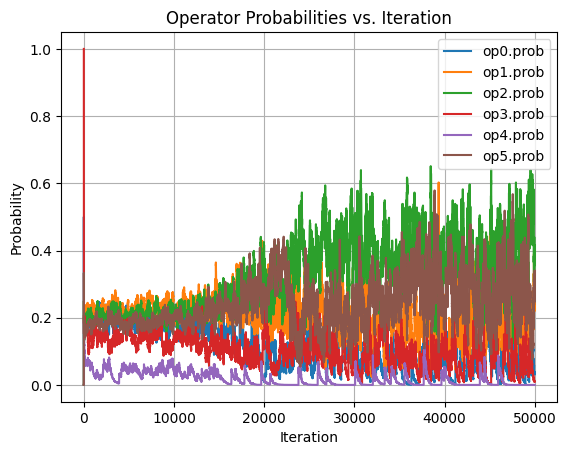

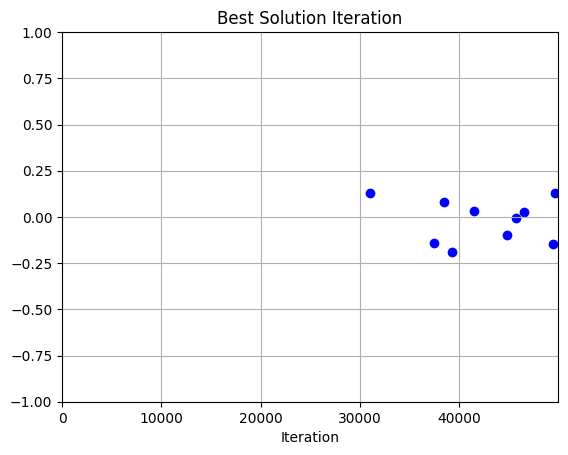

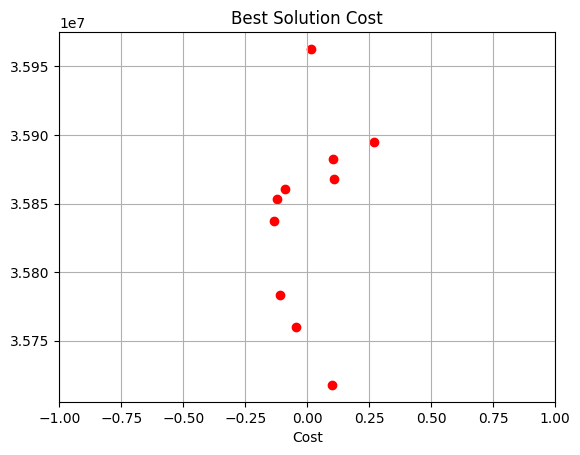

In [9]:
plot(problems[5])